# 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# 2. Load Dataset


In [2]:
df = pd.read_csv("car data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


# 3. Data Inspection

In [3]:
df.shape

df.info()

df.describe()

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


np.int64(2)

# 4. Data Cleaning

In [14]:
df.columns = df.columns.str.strip()

print(df.isnull().sum())

print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64
0


In [15]:
# Clean Categorical Columns

categorical = [
    'Fuel_Type',
    'Seller_Type',
    'Transmission'
]

for col in categorical:
    df[col] = df[col].astype(str).str.strip().str.title()

# Featuring Engineering


In [18]:
# Car Age
current_year = 2025

df["Car_Age"] = current_year - df["Year"]

# Brand Extraction
df["Brand"] = df["Car_Name"].apply(lambda x: x.split()[0])


# Drop Unnecessary Columns 
df.drop(["Year","Car_Name"], axis=1, inplace=True)

# Distribution of Selling Price


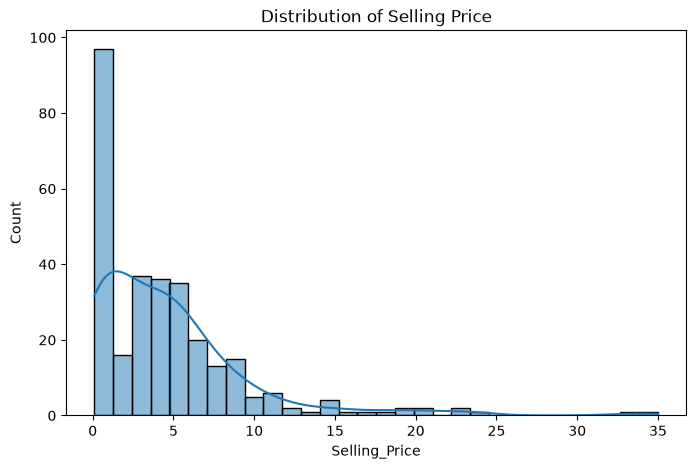

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df["Selling_Price"], bins=30, kde=True)

plt.title("Distribution of Selling Price")

plt.show()

# Price vs Fuel Type

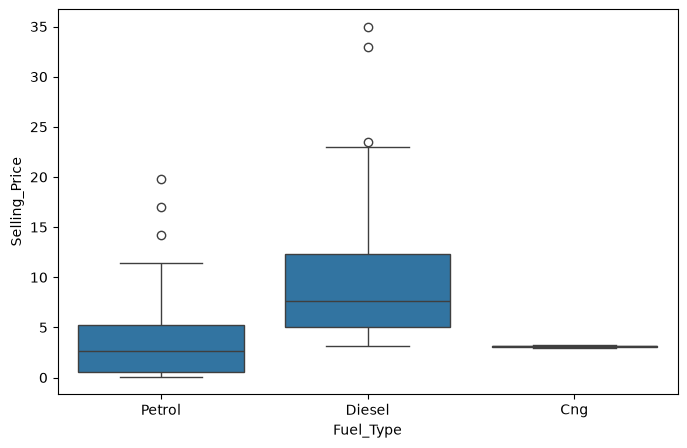

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Fuel_Type",
    y="Selling_Price",
    data=df
)

plt.show()

# Price vs Car Age

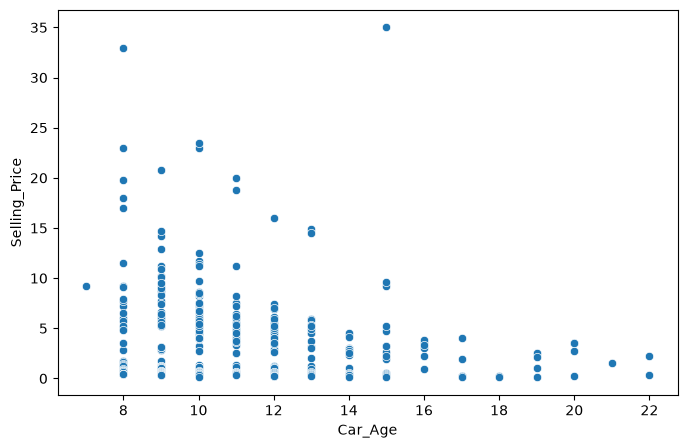

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Car_Age",
    y="Selling_Price",
    data=df
)

plt.show()

# Correlation Heatmap


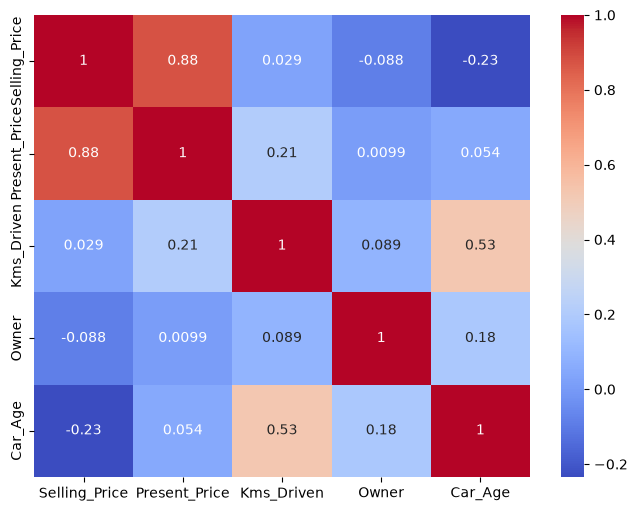

In [22]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

# Features And target


In [23]:
X = df.drop("Selling_Price", axis=1)

y = df["Selling_Price"]

In [24]:
cat_cols = X.select_dtypes(include="object").columns

cat_cols

C:\Users\hp\AppData\Local\Temp\ipykernel_22476\3204409897.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns


Index(['Fuel_Type', 'Seller_Type', 'Transmission', 'Brand'], dtype='str')

# One Hot Encoding

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols
        )
    ],
    remainder="passthrough"
)

# Train-Test Split

In [26]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Linear Regression


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr = Pipeline([
    ("preprocessor",preprocessor),
    ("model",LinearRegression())
])

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

# Random Forest

In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = Pipeline([
    ("preprocessor",preprocessor),
    ("model",RandomForestRegressor(random_state=42))
])

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

# Evaluation

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Linear Regression")

print("MAE :",mean_absolute_error(y_test,pred_lr))
print("RMSE:",np.sqrt(mean_squared_error(y_test,pred_lr)))
print("R2  :",r2_score(y_test,pred_lr))

print()

print("Random Forest")

print("MAE :",mean_absolute_error(y_test,pred_rf))
print("RMSE:",np.sqrt(mean_squared_error(y_test,pred_rf)))
print("R2  :",r2_score(y_test,pred_rf))

Linear Regression
MAE : 1.3481378056538726
RMSE: 2.3889790336805277
R2  : 0.778560402088166

Random Forest
MAE : 1.3777150000000005
RMSE: 3.3423099783682555
R2  : 0.5665649192880164


# Feature Importance

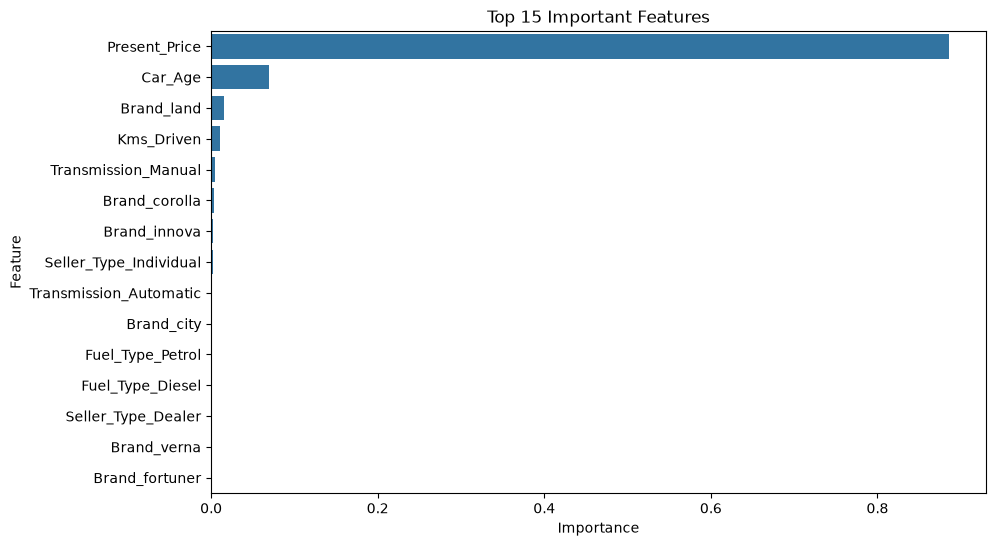

In [30]:
ohe = rf.named_steps['preprocessor'].named_transformers_['cat']

encoded = ohe.get_feature_names_out(cat_cols)

feature_names = list(encoded) + list(
    X.select_dtypes(exclude="object").columns
)

importance = rf.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()